In [7]:
# Import all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset and check the data 
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Column	Description
crim	Per capita crime rate by town
zn	Residential land zoned for large lots
indus	Proportion of non-retail business acres
chas	Charles River dummy variable (1 if near river, else 0)
nox	Nitric oxide concentration
rm	Average number of rooms per dwelling
age	Proportion of old owner-occupied units
dis	Distance to employment centers
rad	Accessibility to radial highways
tax	Property tax rate
ptratio	Pupil-teacher ratio by town
b	Proportion related to Black population index
lstat	Percentage of lower status population
medv	Median value of owner-occupied homes

In [3]:
# Perform train test split
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Create model variable and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# Perform prediction and calculate error
y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MSE: 24.29
R2 Score: 0.67


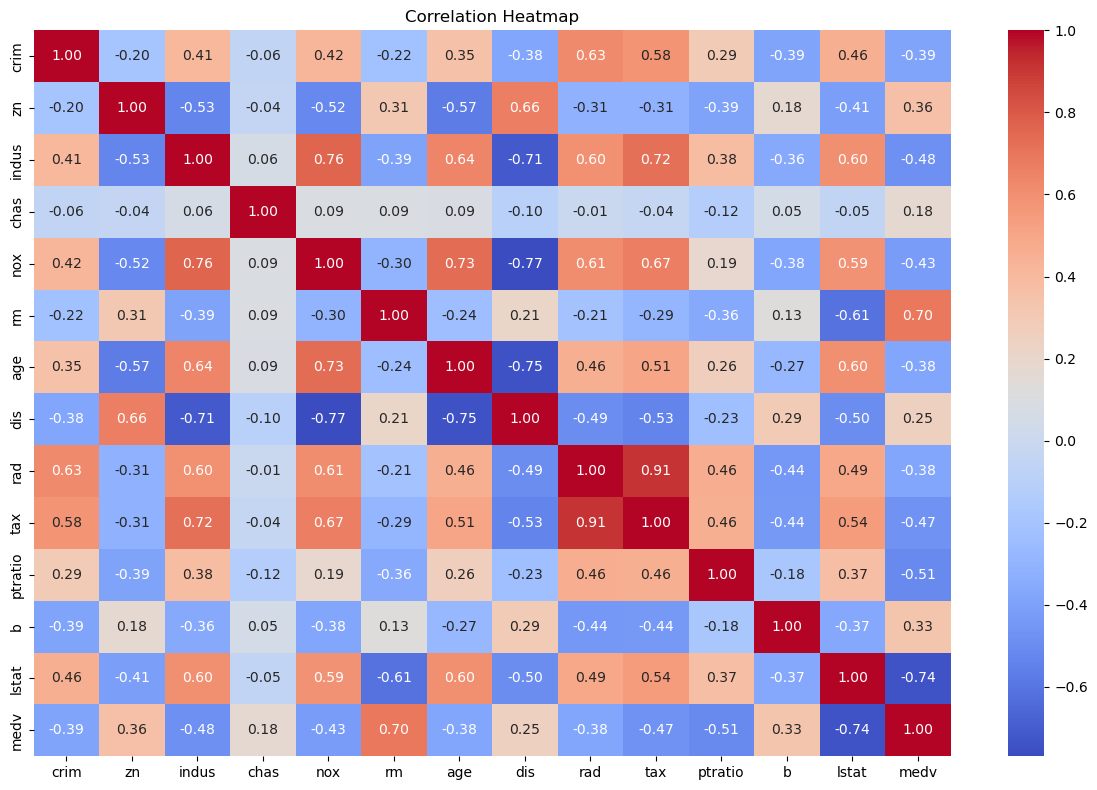

In [8]:
# Correlation heatmap to find most related features with PRICE
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

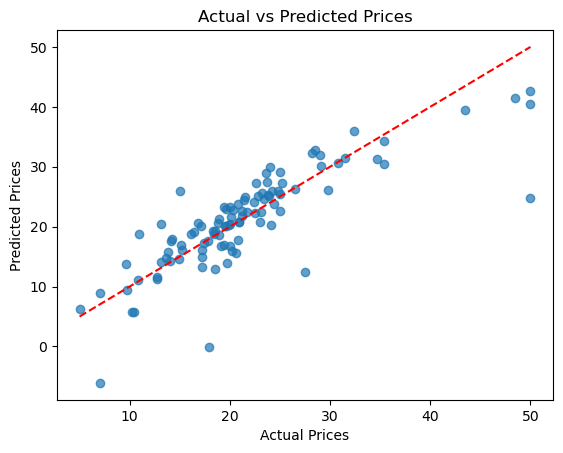

In [9]:
# Plot Actual & Predicted rpice with linear regression line
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [10]:
sample_data = X_test.iloc[0:1]

predicted_price = model.predict(sample_data)

print("Predicted House Price:", predicted_price[0])
print("Actual House Price:", y_test.iloc[0])

Predicted House Price: 28.996723619824785
Actual House Price: 23.6
